In [3]:
import os
# Print every file in your current Jupyter directory
print(os.listdir('.'))

['.ipynb_checkpoints', 'My Music', 'My Pictures', 'My Videos', 'Tekly-Internship', 'Twitch_game_data.csv', 'Untitled.ipynb']


In [3]:
import pandas as pd

# Load only the available game data file
games_df = pd.read_csv('Twitch_game_data.csv', encoding='latin1')

# Inspect the column names, shapes, and data types
print("--- Games Data Overview ---")
games_df.info()

--- Games Data Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              21000 non-null  int64  
 1   Game              20999 non-null  str    
 2   Month             21000 non-null  int64  
 3   Year              21000 non-null  int64  
 4   Hours_watched     21000 non-null  int64  
 5   Hours_streamed    21000 non-null  int64  
 6   Peak_viewers      21000 non-null  int64  
 7   Peak_channels     21000 non-null  int64  
 8   Streamers         21000 non-null  int64  
 9   Avg_viewers       21000 non-null  int64  
 10  Avg_channels      21000 non-null  int64  
 11  Avg_viewer_ratio  21000 non-null  float64
dtypes: float64(1), int64(10), str(1)
memory usage: 1.9 MB


In [4]:
# Aggregate total hours watched per game for each calendar year
yearly_totals = games_df.groupby(['Game', 'Year'])['Hours_watched'].sum().reset_index()

# Extract the absolute peak year and peak hours for every unique game
idx_peak = yearly_totals.groupby('Game')['Hours_watched'].idxmax()
peaks_df = yearly_totals.loc[idx_peak].copy().rename(columns={'Year': 'Peak_Year', 'Hours_watched': 'Peak_Hours'})

# Filter for titles that reached their peak volume prior to 2020
pre_2020_peaks = peaks_df[peaks_df['Peak_Year'] < 2020]

# Dictionary mapping for 2024 performance tracking
hours_2024 = yearly_totals[yearly_totals['Year'] == 2024].set_index('Game')['Hours_watched'].to_dict()

# Evaluate each title's trajectory
eda_results = []
for idx, row in pre_2020_peaks.iterrows():
    name = row['Game']
    p_yr = row['Peak_Year']
    p_hrs = row['Peak_Hours']
    h_24 = hours_2024.get(name, 0) # Returns 0 if game is completely absent in 2024
    
    if h_24 < p_hrs:
        eda_results.append({
            'Game Title': name,
            'Peak_Year': p_yr,
            'Peak_Hours': p_hrs,
            'Hours_2024': h_24,
            'Status': 'Disappeared completely' if h_24 == 0 else 'Declined from peak'
        })

results_df = pd.DataFrame(eda_results)

# Display final outputs to verify assignment metrics
print(f"Q2 - Total games that peaked pre-2020 and fell/vanished by 2024: {len(results_df)}")
print("\nQ3 - Top 10 Highest Performing Legacy Titles from this list:")
print(results_df.sort_values(by='Peak_Hours', ascending=False).head(10))

print("\nQ4 - Top Disappeared Titles (Hitting 0 Hours in 2024):")
print(results_df[results_df['Hours_2024'] == 0].sort_values(by='Peak_Hours', ascending=False).head(10))

Q2 - Total games that peaked pre-2020 and fell/vanished by 2024: 1171

Q3 - Top 10 Highest Performing Legacy Titles from this list:
                         Game Title  Peak_Year  Peak_Hours  Hours_2024  \
350                        Fortnite       2018  1358048914   459393709   
694   PLAYERUNKNOWN'S BATTLEGROUNDS       2017   539829453           0   
417                     Hearthstone       2016   474016816   103616461   
449                             IRL       2018   346370136   116956663   
689                       Overwatch       2018   301791389           0   
125       Call of Duty: Black Ops 4       2018   138898393           0   
126     Call of Duty: Black Ops III       2016   123964703     2599471   
1166              Z1: Battle Royale       2017    89752462           0   
961           Talk Shows & Podcasts       2016    81865580    41333387   
302                         FIFA 19       2019    81052834           0   

                      Status  
350       Declined fro

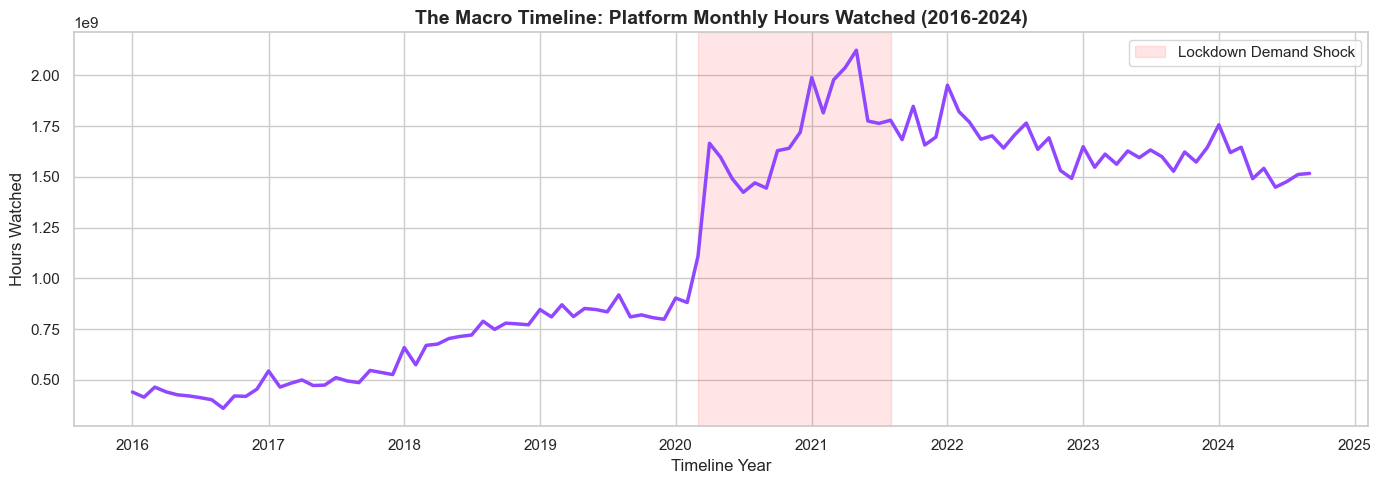

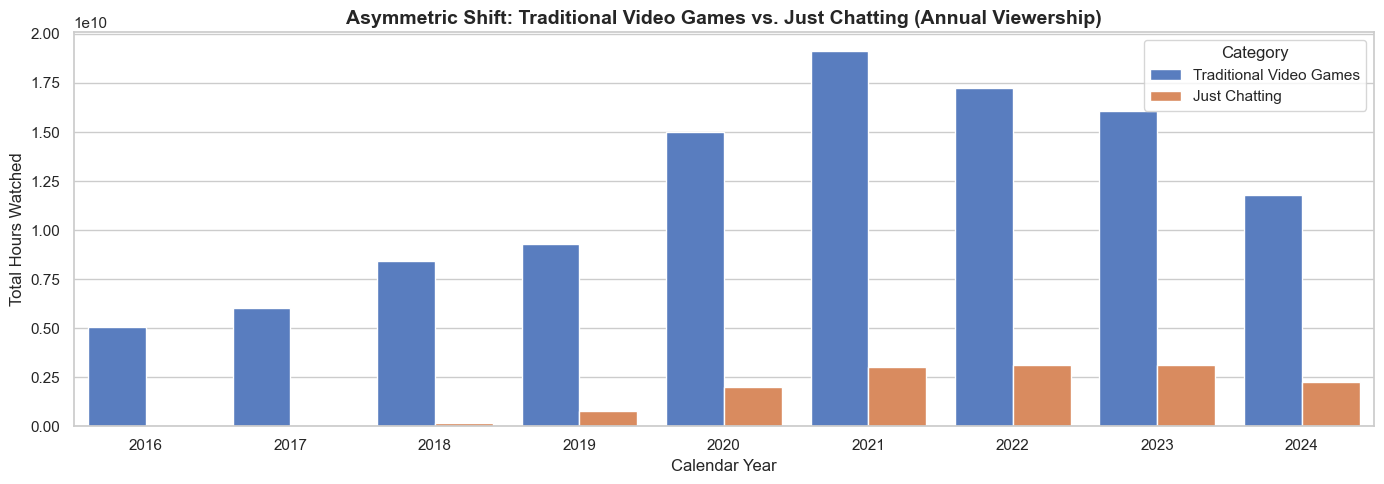

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for professional charts
sns.set_theme(style="whitegrid")

# CRITICAL FIX: Ensure the 'Category' column is created right here before graphing
games_df['Category'] = games_df['Game'].apply(lambda x: 'Just Chatting' if str(x).strip() == 'Just Chatting' else 'Traditional Video Games')

# 1. Prepare continuous timeline data
timeline_df = games_df.groupby(['Year', 'Month'])['Hours_watched'].sum().reset_index()
timeline_df['Date'] = pd.to_datetime(timeline_df['Year'].astype(str) + '-' + timeline_df['Month'].astype(str) + '-01')

# Graph A: The Platform Macro Timeline
plt.figure(figsize=(14, 5))
sns.lineplot(data=timeline_df, x='Date', y='Hours_watched', color='#9146FF', linewidth=2.5) # Twitch Purple
plt.title('The Macro Timeline: Platform Monthly Hours Watched (2016-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline Year', fontsize=12)
plt.ylabel('Hours Watched', fontsize=12)
plt.axvspan('2020-03-01', '2021-08-01', color='red', alpha=0.1, label='Lockdown Demand Shock') # Highlight spike
plt.legend()
plt.tight_layout()
plt.show()

# Graph B: Category Breakdown Over Time
category_timeline = games_df.groupby(['Year', 'Category'])['Hours_watched'].sum().reset_index()
plt.figure(figsize=(14, 5))
sns.barplot(data=category_timeline, x='Year', y='Hours_watched', hue='Category', palette='muted')
plt.title('Asymmetric Shift: Traditional Video Games vs. Just Chatting (Annual Viewership)', fontsize=14, fontweight='bold')
plt.xlabel('Calendar Year', fontsize=12)
plt.ylabel('Total Hours Watched', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# Drop any missing rows in critical columns to clean the ML input matrix
ml_clean = games_df.dropna(subset=['Hours_streamed', 'Peak_viewers', 'Peak_channels', 'Streamers', 'Hours_watched'])

# X = Predictive Features (The inputs)
X = ml_clean[['Hours_streamed', 'Peak_viewers', 'Peak_channels', 'Streamers']]

# y = Target Target Metric (What we want to predict)
y = ml_clean['Hours_watched']

# Split the dataset into train and test branches
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Machine Learning Data Split Complete!")
print(f"Training Rows: {X_train.shape[0]} rows | Evaluation Testing Rows: {X_test.shape[0]} rows")

Machine Learning Data Split Complete!
Training Rows: 16800 rows | Evaluation Testing Rows: 4200 rows


--- Machine Learning Model Results ---
Model R² Predictive Variance Score: 0.9187 (Highly Accurate correlation closer to 1.0)
Mean Absolute Error: 1,802,073.8 hours watched per monthly record



C:\Users\krish\AppData\Local\Temp\ipykernel_18524\3164831282.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


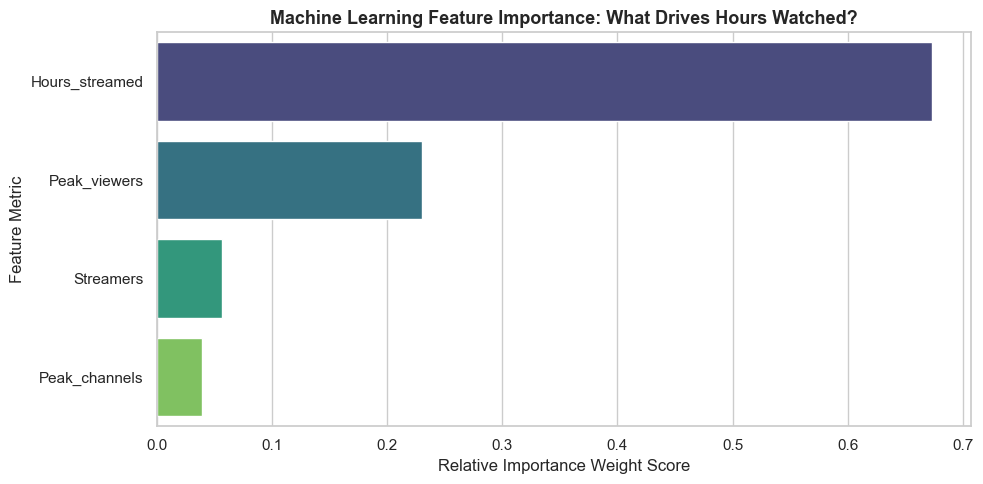

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Instantiate and fit the ML Model (n_jobs=-1 utilizes all CPU cores for speed)
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Run predictions on the unseen testing validation set
predictions = rf_model.predict(X_test)

# Calculate Evaluation Metrics
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"--- Machine Learning Model Results ---")
print(f"Model R² Predictive Variance Score: {r2:.4f} (Highly Accurate correlation closer to 1.0)")
print(f"Mean Absolute Error: {mae:,.1f} hours watched per monthly record\n")

# Extract Feature Importance (Discovering what drives streaming value)
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot the Feature Importance Graph
plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title('Machine Learning Feature Importance: What Drives Hours Watched?', fontsize=13, fontweight='bold')
plt.xlabel('Relative Importance Weight Score')
plt.ylabel('Feature Metric')
plt.tight_layout()
plt.show()